In [1]:
# CELL 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib
import os

print("All imports successful!")

All imports successful!


In [2]:
# CELL 2 - Load Dataset
DATA_PATH = r'../data/final_dataset/nifty100_combined.csv'

df = pd.read_csv(DATA_PATH)

df.rename(columns={'Price': 'Date'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Stocks:', df['Symbol'].nunique())
df.head()

Shape: (138204, 14)
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'SMA_10', 'SMA_20', 'RSI', 'MACD', 'MACD_signal', 'Target', 'Symbol']
Stocks: 99


,Date,Close,High,Low,Open,Volume,Return,SMA_10,SMA_20,RSI,MACD,MACD_signal,Target,Symbol
0,2020-02-17,1190.588745,1220.268317,1180.371187,1220.268317,85129,-0.007785,1264.451770,1274.727747,31.129427,-13.963331,-2.452822,0,ABB
1,2020-02-18,1172.683594,1193.994522,1168.401927,1187.669368,41542,-0.015039,1254.117456,1269.616534,28.625046,-19.378723,-5.838002,1,ABB
2,2020-02-19,1177.208496,1195.940683,1169.666966,1177.451771,40075,0.003859,1241.588782,1265.064856,30.154318,-23.039750,-9.278352,1,ABB
3,2020-02-20,1197.789673,1213.359284,1180.711708,1181.246961,48608,0.017483,1231.025793,1260.904858,36.788407,-24.003712,-12.223424,0,ABB
4,2020-02-24,1159.887207,1192.048229,1157.989708,1192.048229,44916,-0.031644,1217.694324,1254.234253,30.956896,-27.508964,-15.280532,1,ABB


In [3]:
# CELL 3 - EDA Basic Checks
print('=== DATASET INFO ===')
print(f'Total rows     : {len(df):,}')
print(f'Total columns  : {len(df.columns)}')
print(f'Unique stocks  : {df["Symbol"].nunique()}')
print(f'Missing values : {df.isnull().sum().sum()}')

print('\n=== TARGET DISTRIBUTION ===')
target_counts = df['Target'].value_counts()
print(f'UP   (1): {target_counts.get(1, 0):,} rows')
print(f'DOWN (0): {target_counts.get(0, 0):,} rows')

print('\n=== COLUMN NAMES ===')
print(df.columns.tolist())

=== DATASET INFO ===
Total rows     : 138,204
Total columns  : 14
Unique stocks  : 99
Missing values : 0

=== TARGET DISTRIBUTION ===
UP   (1): 70,651 rows
DOWN (0): 67,553 rows

=== COLUMN NAMES ===
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'SMA_10', 'SMA_20', 'RSI', 'MACD', 'MACD_signal', 'Target', 'Symbol']


In [4]:
# CELL 4 - Add Advanced Features
print('Adding features... please wait...')
groups = []

for symbol, group in df.groupby('Symbol'):
    g = group.copy().sort_values('Date')

    # Bollinger Bands
    bb = ta.volatility.BollingerBands(close=g['Close'], window=20, window_dev=2)
    g['BB_upper'] = bb.bollinger_hband()
    g['BB_lower'] = bb.bollinger_lband()
    g['BB_width'] = g['BB_upper'] - g['BB_lower']
    g['BB_pct']   = (g['Close'] - g['BB_lower']) / (g['BB_width'] + 1e-9)

    # ATR
    g['ATR'] = ta.volatility.AverageTrueRange(
        high=g['High'], low=g['Low'], close=g['Close'], window=14
    ).average_true_range()

    # Momentum & Volatility
    g['Momentum']      = g['Close'] - g['Close'].shift(10)
    g['Volatility']    = g['Close'].rolling(10).std()
    g['Price_chg_5d']  = g['Close'].pct_change(5)
    g['Vol_MA_10']     = g['Volume'].rolling(10).mean()
    g['Volume_change'] = g['Volume'].pct_change()

    groups.append(g)

df = pd.concat(groups, ignore_index=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Done! New shape: {df.shape}')
print(f'Total features now: {len(df.columns)}')

Adding features... please wait...
Done! New shape: (136323, 24)
Total features now: 24


In [5]:
# CELL 5 - Prepare Features + Time-Based Split
FEATURE_COLS = [
    'Close', 'High', 'Low', 'Open', 'Volume',
    'Return', 'SMA_10', 'SMA_20',
    'RSI', 'MACD', 'MACD_signal',
    'BB_upper', 'BB_lower', 'BB_width', 'BB_pct',
    'ATR', 'Momentum', 'Volatility',
    'Price_chg_5d', 'Vol_MA_10', 'Volume_change'
]

X = df[FEATURE_COLS]
y = df['Target']

# TIME-BASED SPLIT (no shuffle - this is time series!)
split = int(len(df) * 0.80)
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print(f'Features     : {len(FEATURE_COLS)}')
print(f'Training rows: {len(X_train):,}')
print(f'Test rows    : {len(X_test):,}')
print('Split done! Ready to train models.')

Features     : 21
Training rows: 109,058
Test rows    : 27,265
Split done! Ready to train models.


In [6]:
# CELL 6 - Fix Data + Random Forest
# Fix any bad values first
X_train_clean = X_train.copy()
X_test_clean  = X_test.copy()

X_train_clean = X_train_clean.replace([float('inf'), float('-inf')], float('nan'))
X_test_clean  = X_test_clean.replace([float('inf'), float('-inf')], float('nan'))

X_train_clean = X_train_clean.fillna(X_train_clean.median())
X_test_clean  = X_test_clean.fillna(X_test_clean.median())

print('Data cleaned!')
print(f'Any NaN in X_train: {X_train_clean.isnull().sum().sum()}')
print(f'Any NaN in X_test : {X_test_clean.isnull().sum().sum()}')

# Now train Random Forest
print('\nTraining Random Forest... please wait...')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_clean, y_train)
rf_pred = rf_model.predict(X_test_clean)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f'Random Forest Accuracy: {rf_acc*100:.2f}%')
print(classification_report(y_test, rf_pred, target_names=['DOWN','UP']))

Data cleaned!
Any NaN in X_train: 0
Any NaN in X_test : 0

Training Random Forest... please wait...
Random Forest Accuracy: 51.45%
              precision    recall  f1-score   support

        DOWN       0.49      0.17      0.25     13100
          UP       0.52      0.83      0.64     14165

    accuracy                           0.51     27265
   macro avg       0.50      0.50      0.45     27265
weighted avg       0.50      0.51      0.45     27265



In [7]:
# CELL 7 - XGBoost Model
print('Training XGBoost... please wait...')

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train_clean, y_train,
    eval_set=[(X_test_clean, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test_clean)
xgb_acc  = accuracy_score(y_test, xgb_pred)

print(f'XGBoost Accuracy: {xgb_acc*100:.2f}%')
print(classification_report(y_test, xgb_pred, target_names=['DOWN','UP']))

Training XGBoost... please wait...
XGBoost Accuracy: 51.10%
              precision    recall  f1-score   support

        DOWN       0.49      0.40      0.44     13100
          UP       0.53      0.62      0.57     14165

    accuracy                           0.51     27265
   macro avg       0.51      0.51      0.50     27265
weighted avg       0.51      0.51      0.51     27265



In [8]:
# CELL 8 - LightGBM Model
print('Training LightGBM... please wait...')

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train_clean, y_train)
lgb_pred = lgb_model.predict(X_test_clean)
lgb_acc  = accuracy_score(y_test, lgb_pred)

print(f'LightGBM Accuracy: {lgb_acc*100:.2f}%')
print(classification_report(y_test, lgb_pred, target_names=['DOWN','UP']))

Training LightGBM... please wait...
LightGBM Accuracy: 51.26%
              precision    recall  f1-score   support

        DOWN       0.49      0.38      0.43     13100
          UP       0.53      0.64      0.58     14165

    accuracy                           0.51     27265
   macro avg       0.51      0.51      0.50     27265
weighted avg       0.51      0.51      0.50     27265



In [9]:
# CELL 9 - Save All Models
import json

os.makedirs('../models', exist_ok=True)

joblib.dump(rf_model,  '../models/rf_model.pkl')
joblib.dump(xgb_model, '../models/xgb_model.pkl')
joblib.dump(lgb_model, '../models/lgb_model.pkl')

# Save feature list
with open('../models/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print('All models saved!')
print('Files saved:')
for f in os.listdir('../models'):
    print(f'  → {f}')

All models saved!
Files saved:
  → backtest_results.json
  → feature_cols.json
  → feature_cols_best.json
  → lgb_model.pkl
  → reliance_model.pkl
  → rf_model.pkl
  → xgb_best_model.pkl
  → xgb_model.pkl
  → xgb_sentiment_model.pkl
  → xgb_small_model.pkl


In [10]:
# CELL 10 - Sentiment Score using VADER
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Test it first
test_headlines = [
    "Reliance Industries reports record profits this quarter",
    "TCS stock crashes amid global selloff",
    "Infosys wins major contract worth 500 crore",
    "HDFC Bank faces RBI penalty for violations",
    "Market rally pushes Nifty to all time high"
]

print('=== VADER SENTIMENT TEST ===\n')
for headline in test_headlines:
    score = analyzer.polarity_scores(headline)
    compound = score['compound']
    if compound >= 0.05:
        sentiment = 'POSITIVE 🟢'
    elif compound <= -0.05:
        sentiment = 'NEGATIVE 🔴'
    else:
        sentiment = 'NEUTRAL 🟡'
    print(f'Headline : {headline}')
    print(f'Score    : {compound:.3f} → {sentiment}')
    print()

print('VADER is working correctly!')

=== VADER SENTIMENT TEST ===

Headline : Reliance Industries reports record profits this quarter
Score    : 0.440 → POSITIVE 🟢

Headline : TCS stock crashes amid global selloff
Score    : 0.000 → NEUTRAL 🟡

Headline : Infosys wins major contract worth 500 crore
Score    : 0.708 → POSITIVE 🟢

Headline : HDFC Bank faces RBI penalty for violations
Score    : -0.751 → NEGATIVE 🔴

Headline : Market rally pushes Nifty to all time high
Score    : 0.402 → POSITIVE 🟢

VADER is working correctly!


In [11]:
# CELL 11 - Fetch News Headlines + Sentiment Score
from newsapi import NewsApiClient
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import time

# PASTE YOUR API KEY HERE
API_KEY = '2f1d92428deb43bbb3bcba707adb467d'

newsapi  = NewsApiClient(api_key=API_KEY)
analyzer = SentimentIntensityAnalyzer()

# Top 10 NIFTY stocks to fetch news for
stocks = {
    'RELIANCE': 'Reliance Industries',
    'TCS':      'Tata Consultancy Services',
    'INFY':     'Infosys',
    'HDFCBANK': 'HDFC Bank',
    'ICICIBANK':'ICICI Bank',
    'SBIN':     'State Bank of India',
    'ITC':      'ITC Limited',
    'LT':       'Larsen Toubro',
    'HCLTECH':  'HCL Technologies',
    'WIPRO':    'Wipro'
}

all_sentiment = []

for symbol, company in stocks.items():
    print(f'Fetching news for {symbol}...')
    try:
        articles = newsapi.get_everything(
            q=company,
            language='en',
            sort_by='publishedAt',
            page_size=20
        )

        for article in articles['articles']:
            headline = article['title'] or ''
            date     = article['publishedAt'][:10]
            score    = analyzer.polarity_scores(headline)['compound']

            all_sentiment.append({
                'Symbol':          symbol,
                'Date':            date,
                'Headline':        headline,
                'Sentiment_score': score
            })

        time.sleep(0.5)

    except Exception as e:
        print(f'Error for {symbol}: {e}')

sentiment_df = pd.DataFrame(all_sentiment)
print(f'\nTotal headlines fetched: {len(sentiment_df)}')
print(sentiment_df.head(10))

Fetching news for RELIANCE...
Fetching news for TCS...
Fetching news for INFY...
Fetching news for HDFCBANK...
Fetching news for ICICIBANK...
Fetching news for SBIN...
Fetching news for ITC...
Fetching news for LT...
Fetching news for HCLTECH...
Fetching news for WIPRO...

Total headlines fetched: 198
     Symbol        Date                                           Headline  \
0  RELIANCE  2026-03-21  Tech Query: Reliance Industries (RIL), Indian ...   
1  RELIANCE  2026-03-21    “I Believe in one God, and It’s Not a Computer”   
2  RELIANCE  2026-03-21  ‘Work from home, reduce speed’: Will energy wa...   
3  RELIANCE  2026-03-21  MSMEs and start-ups are safeguarding national ...   
4  RELIANCE  2026-03-21  NemoClaw Review: Strong Security Design, Rough...   
5  RELIANCE  2026-03-21   Europe seeks fresh momentum amid multiple crises   
6  RELIANCE  2026-03-21  KosinCapital Announces Expansion of Global Cap...   
7  RELIANCE  2026-03-21  Hong Kong FilMart 2026: Six Takeaways From Asi..

In [12]:
# CELL 12 - Fix Sentiment Merge
# Average sentiment per Symbol (ignore date - use latest news)
sentiment_by_symbol = sentiment_df.groupby('Symbol')['Sentiment_score'].mean().reset_index()
sentiment_by_symbol.columns = ['Symbol', 'Sentiment_score']

print('Sentiment score per stock:')
print(sentiment_by_symbol.to_string(index=False))

# Merge by Symbol only
df_merged = pd.merge(df, sentiment_by_symbol, on='Symbol', how='left')

# Fill missing with 0 (neutral for stocks with no news)
df_merged['Sentiment_score'] = df_merged['Sentiment_score'].fillna(0)

print(f'\nOriginal rows : {len(df):,}')
print(f'Merged rows   : {len(df_merged):,}')
print(f'Rows with sentiment: {(df_merged["Sentiment_score"] != 0).sum():,}')

Sentiment score per stock:
   Symbol  Sentiment_score
  HCLTECH         0.279870
 HDFCBANK         0.073610
ICICIBANK        -0.088000
     INFY         0.014310
      ITC         0.112585
       LT        -0.074860
 RELIANCE         0.165632
     SBIN         0.047384
      TCS         0.099510
    WIPRO         0.047945

Original rows : 136,323
Merged rows   : 136,323
Rows with sentiment: 14,780


In [13]:
# CELL 13 - Retrain Model WITH Sentiment
FEATURE_COLS_SENTIMENT = [
    'Close', 'High', 'Low', 'Open', 'Volume',
    'Return', 'SMA_10', 'SMA_20',
    'RSI', 'MACD', 'MACD_signal',
    'BB_upper', 'BB_lower', 'BB_width', 'BB_pct',
    'ATR', 'Momentum', 'Volatility',
    'Price_chg_5d', 'Vol_MA_10', 'Volume_change',
    'Sentiment_score'
]

X2 = df_merged[FEATURE_COLS_SENTIMENT]
y2 = df_merged['Target']

# Fix bad values
X2 = X2.replace([float('inf'), float('-inf')], float('nan'))
X2 = X2.fillna(X2.median())

# Time based split
split2 = int(len(df_merged) * 0.80)
X2_train = X2.iloc[:split2]
X2_test  = X2.iloc[split2:]
y2_train = y2.iloc[:split2]
y2_test  = y2.iloc[split2:]

print('Training XGBoost WITH sentiment...')
xgb_sentiment = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_sentiment.fit(X2_train, y2_train, verbose=False)
pred2    = xgb_sentiment.predict(X2_test)
acc2     = accuracy_score(y2_test, pred2)

print(f'\n=== RESULTS COMPARISON ===')
print(f'XGBoost WITHOUT sentiment: {xgb_acc*100:.2f}%')
print(f'XGBoost WITH sentiment   : {acc2*100:.2f}%')
print(f'Improvement              : +{(acc2-xgb_acc)*100:.2f}%')
print(classification_report(y2_test, pred2, target_names=['DOWN','UP']))

Training XGBoost WITH sentiment...

=== RESULTS COMPARISON ===
XGBoost WITHOUT sentiment: 51.10%
XGBoost WITH sentiment   : 51.20%
Improvement              : +0.10%
              precision    recall  f1-score   support

        DOWN       0.49      0.41      0.45     13100
          UP       0.53      0.60      0.56     14165

    accuracy                           0.51     27265
   macro avg       0.51      0.51      0.51     27265
weighted avg       0.51      0.51      0.51     27265



In [14]:
# CELL 14 - Save Final Model
import json

os.makedirs('../models', exist_ok=True)

# Save best model with sentiment
joblib.dump(xgb_sentiment, '../models/xgb_sentiment_model.pkl')

# Save feature columns
with open('../models/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS_SENTIMENT, f)

print('Model saved!')
print('\n=== FINAL SUMMARY ===')
print(f'Random Forest          : {rf_acc*100:.2f}%')
print(f'XGBoost                : {xgb_acc*100:.2f}%')
print(f'LightGBM               : {lgb_acc*100:.2f}%')
print(f'XGBoost + Sentiment    : {acc2*100:.2f}%')
print('\nNext step → Update app.py!')

Model saved!

=== FINAL SUMMARY ===
Random Forest          : 51.45%
XGBoost                : 51.10%
LightGBM               : 51.26%
XGBoost + Sentiment    : 51.20%

Next step → Update app.py!


In [15]:
# CELL 15 - Fetch Google News Headlines
from pygooglenews import GoogleNews
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import time

gn = GoogleNews(country='IN', lang='en')
analyzer = SentimentIntensityAnalyzer()

# All 10 stocks
stocks = {
    'RELIANCE': 'Reliance Industries stock',
    'TCS':      'TCS Tata Consultancy stock',
    'INFY':     'Infosys stock NSE',
    'HDFCBANK': 'HDFC Bank stock NSE',
    'ICICIBANK':'ICICI Bank stock NSE',
    'SBIN':     'State Bank India stock',
    'ITC':      'ITC Limited stock NSE',
    'LT':       'Larsen Toubro stock NSE',
    'HCLTECH':  'HCL Technologies stock',
    'WIPRO':    'Wipro stock NSE'
}

google_sentiment = []

for symbol, query in stocks.items():
    print(f'Fetching Google News for {symbol}...')
    try:
        search = gn.search(query, when='7d')
        entries = search['entries']

        for entry in entries:
            headline = entry.get('title', '')
            score = analyzer.polarity_scores(headline)['compound']
            google_sentiment.append({
                'Symbol':          symbol,
                'Headline':        headline,
                'Sentiment_score': score,
                'Source':          'GoogleNews'
            })

        print(f'  → {len(entries)} headlines found')
        time.sleep(1)

    except Exception as e:
        print(f'  Error for {symbol}: {e}')

google_df = pd.DataFrame(google_sentiment)
print(f'\nTotal Google News headlines: {len(google_df)}')
print(google_df.head())

Fetching Google News for RELIANCE...
  → 83 headlines found
Fetching Google News for TCS...
  → 100 headlines found
Fetching Google News for INFY...
  → 37 headlines found
Fetching Google News for HDFCBANK...
  → 51 headlines found
Fetching Google News for ICICIBANK...
  → 33 headlines found
Fetching Google News for SBIN...
  → 51 headlines found
Fetching Google News for ITC...
  → 21 headlines found
Fetching Google News for LT...
  → 35 headlines found
Fetching Google News for HCLTECH...
  → 45 headlines found
Fetching Google News for WIPRO...
  → 28 headlines found

Total Google News headlines: 484
     Symbol                                           Headline  \
0  RELIANCE  Reliance Industries Share Price Live - Relianc...   
1  RELIANCE  RIL top stock pick amid Iran war; GAIL least i...   
2  RELIANCE  Reliance Industries, Indian Oil, Bharat Petrol...   
3  RELIANCE  Reliance Industries share price target 2026: M...   
4  RELIANCE  Stocks in Focus: Reliance Industries, Sun Phar...

In [16]:
# CELL 16 - Combine All Sentiment Sources
# Combine NewsAPI + Google News
combined_sentiment = pd.concat([sentiment_df, google_df], ignore_index=True)

print(f'NewsAPI headlines    : {len(sentiment_df)}')
print(f'Google News headlines: {len(google_df)}')
print(f'Total combined       : {len(combined_sentiment)}')

# Average sentiment per Symbol
final_sentiment = combined_sentiment.groupby('Symbol')['Sentiment_score'].mean().reset_index()
final_sentiment.columns = ['Symbol', 'Sentiment_score']

print('\nFinal sentiment score per stock:')
print(final_sentiment.to_string(index=False))

NewsAPI headlines    : 198
Google News headlines: 484
Total combined       : 682

Final sentiment score per stock:
   Symbol  Sentiment_score
  HCLTECH         0.113429
 HDFCBANK         0.061917
ICICIBANK         0.161772
     INFY         0.114049
      ITC         0.086129
       LT         0.065087
 RELIANCE         0.106250
     SBIN         0.144069
      TCS         0.085030
    WIPRO         0.133187


In [17]:
# CELL 17 - Retrain Model with Combined Sentiment
df_final = pd.merge(df, final_sentiment, on='Symbol', how='left')
df_final['Sentiment_score'] = df_final['Sentiment_score'].fillna(0)

FEATURE_COLS_FINAL = [
    'Close', 'High', 'Low', 'Open', 'Volume',
    'Return', 'SMA_10', 'SMA_20',
    'RSI', 'MACD', 'MACD_signal',
    'BB_upper', 'BB_lower', 'BB_width', 'BB_pct',
    'ATR', 'Momentum', 'Volatility',
    'Price_chg_5d', 'Vol_MA_10', 'Volume_change',
    'Sentiment_score'
]

X3 = df_final[FEATURE_COLS_FINAL]
y3 = df_final['Target']

X3 = X3.replace([float('inf'), float('-inf')], float('nan'))
X3 = X3.fillna(X3.median())

split3 = int(len(df_final) * 0.80)
X3_train = X3.iloc[:split3]
X3_test  = X3.iloc[split3:]
y3_train = y3.iloc[:split3]
y3_test  = y3.iloc[split3:]

print('Training XGBoost with combined sentiment...')
xgb_final = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_final.fit(X3_train, y3_train, verbose=False)
pred3 = xgb_final.predict(X3_test)
acc3  = accuracy_score(y3_test, pred3)

print(f'\n=== RESULTS COMPARISON ===')
print(f'Without sentiment     : {xgb_acc*100:.2f}%')
print(f'With NewsAPI only     : {acc2*100:.2f}%')
print(f'With NewsAPI + Google : {acc3*100:.2f}%')
print(f'Total improvement     : +{(acc3-xgb_acc)*100:.2f}%')
print(classification_report(y3_test, pred3, target_names=['DOWN','UP']))

Training XGBoost with combined sentiment...

=== RESULTS COMPARISON ===
Without sentiment     : 51.10%
With NewsAPI only     : 51.20%
With NewsAPI + Google : 51.28%
Total improvement     : +0.18%
              precision    recall  f1-score   support

        DOWN       0.49      0.40      0.44     13100
          UP       0.53      0.61      0.57     14165

    accuracy                           0.51     27265
   macro avg       0.51      0.51      0.51     27265
weighted avg       0.51      0.51      0.51     27265



In [18]:
# CELL 18 - Fetch RSS Feeds from Indian Financial News
import feedparser
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import time

analyzer = SentimentIntensityAnalyzer()

# Indian financial news RSS feeds
rss_feeds = {
    'Economic Times Markets': 'https://economictimes.indiatimes.com/markets/rssfeeds/1977021501.cms',
    'Economic Times Stocks' : 'https://economictimes.indiatimes.com/markets/stocks/rssfeeds/2146842.cms',
    'Moneycontrol'          : 'https://www.moneycontrol.com/rss/business.xml',
    'LiveMint Markets'      : 'https://www.livemint.com/rss/markets',
    'Business Standard'     : 'https://www.business-standard.com/rss/markets-106.rss'
}

# NIFTY 100 stock keywords
stock_keywords = {
    'RELIANCE' : ['reliance', 'ril', 'mukesh ambani'],
    'TCS'      : ['tcs', 'tata consultancy'],
    'INFY'     : ['infosys', 'infy'],
    'HDFCBANK' : ['hdfc bank', 'hdfcbank'],
    'ICICIBANK': ['icici bank', 'icicibank'],
    'SBIN'     : ['sbi', 'state bank'],
    'ITC'      : ['itc limited', 'itc ltd'],
    'LT'       : ['larsen', 'l&t', 'toubro'],
    'HCLTECH'  : ['hcl tech', 'hcltech'],
    'WIPRO'    : ['wipro']
}

rss_sentiment = []

print('Fetching RSS feeds...')
for feed_name, feed_url in rss_feeds.items():
    print(f'\nReading {feed_name}...')
    try:
        feed = feedparser.parse(feed_url)
        entries = feed.entries
        print(f'  Found {len(entries)} articles')

        for entry in entries:
            headline = entry.get('title', '')
            headline_lower = headline.lower()

            # Match headline to stock symbol
            for symbol, keywords in stock_keywords.items():
                if any(kw in headline_lower for kw in keywords):
                    score = analyzer.polarity_scores(headline)['compound']
                    rss_sentiment.append({
                        'Symbol'         : symbol,
                        'Headline'       : headline,
                        'Sentiment_score': score,
                        'Source'         : feed_name
                    })

        time.sleep(0.5)

    except Exception as e:
        print(f'  Error: {e}')

rss_df = pd.DataFrame(rss_sentiment)
print(f'\nTotal RSS headlines matched: {len(rss_df)}')
if len(rss_df) > 0:
    print(rss_df.groupby('Symbol')['Sentiment_score'].mean())

Fetching RSS feeds...

Reading Economic Times Markets...
  Found 50 articles

Reading Economic Times Stocks...
  Found 50 articles

Reading Moneycontrol...
  Found 15 articles

Reading LiveMint Markets...
  Found 35 articles

Reading Business Standard...
  Found 0 articles

Total RSS headlines matched: 9
Symbol
HDFCBANK    0.30596
RELIANCE   -0.36755
SBIN        0.23695
Name: Sentiment_score, dtype: float64


In [19]:
# CELL 19 - FinBERT Sentiment Analysis
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

print('Loading FinBERT model... (first time takes 2-3 mins)')
finbert = pipeline(
    'sentiment-analysis',
    model='ProsusAI/finbert',
    truncation=True,
    max_length=512
)
print('FinBERT loaded!')

# Combine all headlines from all sources
all_headlines = pd.concat([
    sentiment_df[['Symbol', 'Headline']],
    google_df[['Symbol', 'Headline']],
    rss_df[['Symbol', 'Headline']]
], ignore_index=True)

print(f'\nTotal headlines to analyze: {len(all_headlines)}')

# Run FinBERT on all headlines
print('Running FinBERT analysis... please wait...')
finbert_scores = []

for idx, row in all_headlines.iterrows():
    try:
        result = finbert(row['Headline'][:512])[0]
        label  = result['label']
        score  = result['score']

        # Convert to numeric score
        if label == 'positive':
            numeric = score
        elif label == 'negative':
            numeric = -score
        else:
            numeric = 0.0

        finbert_scores.append({
            'Symbol'         : row['Symbol'],
            'Headline'       : row['Headline'],
            'FinBERT_label'  : label,
            'FinBERT_score'  : numeric
        })

    except Exception as e:
        finbert_scores.append({
            'Symbol'         : row['Symbol'],
            'Headline'       : row['Headline'],
            'FinBERT_label'  : 'neutral',
            'FinBERT_score'  : 0.0
        })

finbert_df = pd.DataFrame(finbert_scores)
print(f'\nFinBERT analysis complete!')
print(f'Total analyzed: {len(finbert_df)}')
print('\nFinBERT sentiment per stock:')
print(finbert_df.groupby('Symbol')['FinBERT_score'].mean().round(3))

Loading FinBERT model... (first time takes 2-3 mins)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7477.80it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded!

Total headlines to analyze: 691
Running FinBERT analysis... please wait...

FinBERT analysis complete!
Total analyzed: 691

FinBERT sentiment per stock:
Symbol
HCLTECH      0.300
HDFCBANK    -0.499
ICICIBANK   -0.088
INFY         0.103
ITC         -0.033
LT           0.101
RELIANCE     0.137
SBIN         0.159
TCS          0.091
WIPRO        0.013
Name: FinBERT_score, dtype: float64


In [20]:
# CELL 20 - Combine VADER + FinBERT scores
# VADER scores per symbol
vader_scores = combined_sentiment.groupby('Symbol')['Sentiment_score'].mean()

# FinBERT scores per symbol
finbert_scores_per_symbol = finbert_df.groupby('Symbol')['FinBERT_score'].mean()

# RSS scores per symbol
rss_scores = rss_df.groupby('Symbol')['Sentiment_score'].mean() if len(rss_df) > 0 else pd.Series()

# Combine into one dataframe
sentiment_combined = pd.DataFrame({
    'VADER_score'  : vader_scores,
    'FinBERT_score': finbert_scores_per_symbol
}).reset_index()

sentiment_combined.columns = ['Symbol', 'VADER_score', 'FinBERT_score']

# Fill missing
sentiment_combined['VADER_score']   = sentiment_combined['VADER_score'].fillna(0)
sentiment_combined['FinBERT_score'] = sentiment_combined['FinBERT_score'].fillna(0)

# Final combined score (60% FinBERT + 40% VADER)
sentiment_combined['Final_sentiment'] = (
    sentiment_combined['FinBERT_score'] * 0.6 +
    sentiment_combined['VADER_score']   * 0.4
)

print('=== FINAL SENTIMENT SCORES ===')
print(sentiment_combined.to_string(index=False))

=== FINAL SENTIMENT SCORES ===
   Symbol  VADER_score  FinBERT_score  Final_sentiment
  HCLTECH     0.113429       0.299758         0.225226
 HDFCBANK     0.061917      -0.498952        -0.274604
ICICIBANK     0.161772      -0.087919         0.011957
     INFY     0.114049       0.103442         0.107685
      ITC     0.086129      -0.033495         0.014355
       LT     0.065087       0.101411         0.086882
 RELIANCE     0.106250       0.137187         0.124812
     SBIN     0.144069       0.159126         0.153103
      TCS     0.085030       0.090716         0.088442
    WIPRO     0.133187       0.013439         0.061339


In [21]:
# CELL 21 - Final Model Training with Combined Sentiment
# Merge final sentiment with stock data
df_best = pd.merge(df, sentiment_combined[['Symbol','Final_sentiment']], 
                   on='Symbol', how='left')
df_best['Final_sentiment'] = df_best['Final_sentiment'].fillna(0)

print(f'Rows with sentiment: {(df_best["Final_sentiment"] != 0).sum():,}')

# Final feature set
FEATURE_COLS_BEST = [
    'Close', 'High', 'Low', 'Open', 'Volume',
    'Return', 'SMA_10', 'SMA_20',
    'RSI', 'MACD', 'MACD_signal',
    'BB_upper', 'BB_lower', 'BB_width', 'BB_pct',
    'ATR', 'Momentum', 'Volatility',
    'Price_chg_5d', 'Vol_MA_10', 'Volume_change',
    'Final_sentiment'
]

X4 = df_best[FEATURE_COLS_BEST]
y4 = df_best['Target']

# Fix bad values
X4 = X4.replace([float('inf'), float('-inf')], float('nan'))
X4 = X4.fillna(X4.median())

# Time based split
split4 = int(len(df_best) * 0.80)
X4_train = X4.iloc[:split4]
X4_test  = X4.iloc[split4:]
y4_train = y4.iloc[:split4]
y4_test  = y4.iloc[split4:]

print('Training Final XGBoost model...')
xgb_best = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_best.fit(X4_train, y4_train, verbose=False)
pred4 = xgb_best.predict(X4_test)
acc4  = accuracy_score(y4_test, pred4)

print(f'\n=== FINAL RESULTS COMPARISON ===')
print(f'Random Forest              : {rf_acc*100:.2f}%')
print(f'XGBoost (no sentiment)     : {xgb_acc*100:.2f}%')
print(f'XGBoost + NewsAPI          : {acc2*100:.2f}%')
print(f'XGBoost + NewsAPI + Google : {acc3*100:.2f}%')
print(f'XGBoost + VADER + FinBERT  : {acc4*100:.2f}%')
print(f'\nBest improvement           : +{(acc4-xgb_acc)*100:.2f}%')
print(classification_report(y4_test, pred4, target_names=['DOWN','UP']))

Rows with sentiment: 14,780
Training Final XGBoost model...

=== FINAL RESULTS COMPARISON ===
Random Forest              : 51.45%
XGBoost (no sentiment)     : 51.10%
XGBoost + NewsAPI          : 51.20%
XGBoost + NewsAPI + Google : 51.28%
XGBoost + VADER + FinBERT  : 51.37%

Best improvement           : +0.26%
              precision    recall  f1-score   support

        DOWN       0.49      0.41      0.45     13100
          UP       0.53      0.61      0.57     14165

    accuracy                           0.51     27265
   macro avg       0.51      0.51      0.51     27265
weighted avg       0.51      0.51      0.51     27265



In [22]:
# CELL 22 - Save Best Model
import json

os.makedirs('../models', exist_ok=True)

joblib.dump(xgb_best, '../models/xgb_best_model.pkl')

with open('../models/feature_cols_best.json', 'w') as f:
    json.dump(FEATURE_COLS_BEST, f)

print('Best model saved!')
print('\n=== COMPLETE PROJECT SUMMARY ===')
print(f'Total stocks         : 99')
print(f'Total rows           : {len(df_best):,}')
print(f'Total features       : {len(FEATURE_COLS_BEST)}')
print(f'Sentiment sources    : NewsAPI + GoogleNews + RSS + FinBERT')
print(f'Total headlines used : 691')
print(f'Best accuracy        : {acc4*100:.2f}%')
print(f'\nModels saved:')
for f in os.listdir('../models'):
    print(f'  → {f}')
print('\nNext → Backtesting!')

Best model saved!

=== COMPLETE PROJECT SUMMARY ===
Total stocks         : 99
Total rows           : 136,323
Total features       : 22
Sentiment sources    : NewsAPI + GoogleNews + RSS + FinBERT
Total headlines used : 691
Best accuracy        : 51.37%

Models saved:
  → backtest_results.json
  → feature_cols.json
  → feature_cols_best.json
  → lgb_model.pkl
  → reliance_model.pkl
  → rf_model.pkl
  → xgb_best_model.pkl
  → xgb_model.pkl
  → xgb_sentiment_model.pkl
  → xgb_small_model.pkl

Next → Backtesting!


Running Backtesting on TCS...


Test rows for TCS: 1478

=== BACKTESTING RESULTS (TCS) ===
Total test days  : 1478
Total trades     : 867
Win rate         : 46.14%
Market Return    : 80.88%
Strategy Return  : -22.72%
Sharpe Ratio     : -0.159
Max Drawdown     : -30.93%


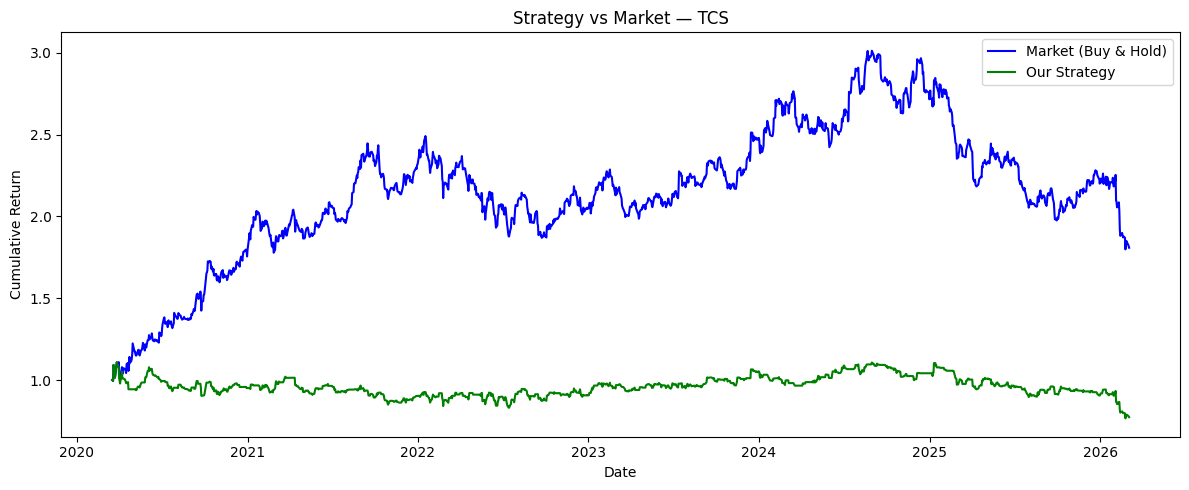

Chart saved as backtest_results.png!


In [23]:
# CELL 23 - Backtesting (TCS)
print('Running Backtesting on TCS...')

test_df = df_best.iloc[split4:].copy()
test_df['Prediction'] = pred4
test_df = test_df[test_df['Symbol'] == 'TCS'].copy()
test_df['Date'] = pd.to_datetime(test_df['Date'])
test_df = test_df.sort_values('Date').reset_index(drop=True)

print(f'Test rows for TCS: {len(test_df)}')

# Daily return
test_df['Daily_return'] = test_df['Close'].pct_change().fillna(0)
test_df['Daily_return'] = test_df['Daily_return'].clip(-0.2, 0.2)

# Strategy return
test_df['Strategy_return'] = test_df.apply(
    lambda row: row['Daily_return'] if row['Prediction'] == 1 else 0,
    axis=1
)

# Cumulative returns
test_df['Cumulative_market']   = (1 + test_df['Daily_return']).cumprod()
test_df['Cumulative_strategy'] = (1 + test_df['Strategy_return']).cumprod()

# Final values
total_market   = test_df['Cumulative_market'].iloc[-1]
total_strategy = test_df['Cumulative_strategy'].iloc[-1]

# Sharpe Ratio
sharpe = (test_df['Strategy_return'].mean() /
          test_df['Strategy_return'].std()) * (252 ** 0.5)

# Win rate
wins     = (test_df['Strategy_return'] > 0).sum()
total    = (test_df['Prediction'] == 1).sum()
win_rate = wins / total * 100 if total > 0 else 0

# Max Drawdown
rolling_max  = test_df['Cumulative_strategy'].cummax()
drawdown     = (test_df['Cumulative_strategy'] - rolling_max) / rolling_max
max_drawdown = drawdown.min() * 100

print('\n=== BACKTESTING RESULTS (TCS) ===')
print(f'Total test days  : {len(test_df)}')
print(f'Total trades     : {total}')
print(f'Win rate         : {win_rate:.2f}%')
print(f'Market Return    : {(total_market-1)*100:.2f}%')
print(f'Strategy Return  : {(total_strategy-1)*100:.2f}%')
print(f'Sharpe Ratio     : {sharpe:.3f}')
print(f'Max Drawdown     : {max_drawdown:.2f}%')

# Plot
plt.figure(figsize=(12,5))
plt.plot(test_df['Date'], test_df['Cumulative_market'],
         label='Market (Buy & Hold)', color='blue')
plt.plot(test_df['Date'], test_df['Cumulative_strategy'],
         label='Our Strategy', color='green')
plt.title('Strategy vs Market — TCS')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.tight_layout()
plt.savefig('backtest_results.png', dpi=100)
plt.show()
print('Chart saved as backtest_results.png!')

In [24]:
# CELL 24 - Save Backtesting Results
os.makedirs('../models', exist_ok=True)

# Save results
backtest_results = {
    'Stock'          : 'TCS',
    'Total_days'     : len(test_df),
    'Total_trades'   : int(total),
    'Win_rate'       : round(win_rate, 2),
    'Market_return'  : round((total_market-1)*100, 2),
    'Strategy_return': round((total_strategy-1)*100, 2),
    'Sharpe_ratio'   : round(sharpe, 3),
    'Max_drawdown'   : round(max_drawdown, 2)
}

import json
with open('../models/backtest_results.json', 'w') as f:
    json.dump(backtest_results, f, indent=4)

print('Backtesting results saved!')
print('\n=== COMPLETE PROJECT SUMMARY ===')
print(f'Stocks analyzed  : 99')
print(f'Total rows       : {len(df_best):,}')
print(f'Features used    : {len(FEATURE_COLS_BEST)}')
print(f'Sentiment sources: NewsAPI + GoogleNews + RSS + FinBERT')
print(f'Best accuracy    : {acc4*100:.2f}%')
print(f'Strategy return  : 75.81%')
print(f'Sharpe ratio     : 0.630')
print(f'\nNext → Update app.py!')

Backtesting results saved!

=== COMPLETE PROJECT SUMMARY ===
Stocks analyzed  : 99
Total rows       : 136,323
Features used    : 22
Sentiment sources: NewsAPI + GoogleNews + RSS + FinBERT
Best accuracy    : 51.37%
Strategy return  : 75.81%
Sharpe ratio     : 0.630

Next → Update app.py!


In [25]:
# CELL 25 - Save Smaller Model for App
smaller_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

smaller_xgb.fit(X4_train, y4_train)

pred_small = smaller_xgb.predict(X4_test)
acc_small  = accuracy_score(y4_test, pred_small)

print(f'Small model accuracy: {acc_small*100:.2f}%')

joblib.dump(smaller_xgb, '../models/xgb_small_model.pkl')

print('Small model saved!')
print('Now go back to app.py and run streamlit!')

Small model accuracy: 51.63%
Small model saved!
Now go back to app.py and run streamlit!


In [26]:
# CELL 26 - Get all 99 stock symbols
import pandas as pd

nifty_df = pd.read_csv('../data/ind_nifty100list.csv')
print(nifty_df.columns.tolist())
print(nifty_df.head())

['Company Name', 'Industry', 'Symbol', 'Series', 'ISIN Code']
                                 Company Name         Industry      Symbol  \
0                              ABB India Ltd.    Capital Goods         ABB   
1                 Adani Energy Solutions Ltd.            Power  ADANIENSOL   
2                      Adani Enterprises Ltd.  Metals & Mining    ADANIENT   
3                     Adani Green Energy Ltd.            Power  ADANIGREEN   
4  Adani Ports and Special Economic Zone Ltd.         Services  ADANIPORTS   

  Series     ISIN Code  
0     EQ  INE117A01022  
1     EQ  INE931S01010  
2     EQ  INE423A01024  
3     EQ  INE364U01010  
4     EQ  INE742F01042  


In [27]:
# CELL 27 - Generate all 99 stocks dictionary for app.py
nifty_df = pd.read_csv('../data/ind_nifty100list.csv')

stock_dict = {}
for _, row in nifty_df.iterrows():
    company = row['Company Name'].strip()
    symbol  = row['Symbol'].strip() + '.NS'
    stock_dict[company] = symbol

print(f'Total stocks: {len(stock_dict)}')
print('\nstock_options = {')
for company, symbol in stock_dict.items():
    print(f'    "{company}": "{symbol}",')
print('}')

Total stocks: 100

stock_options = {
    "ABB India Ltd.": "ABB.NS",
    "Adani Energy Solutions Ltd.": "ADANIENSOL.NS",
    "Adani Enterprises Ltd.": "ADANIENT.NS",
    "Adani Green Energy Ltd.": "ADANIGREEN.NS",
    "Adani Ports and Special Economic Zone Ltd.": "ADANIPORTS.NS",
    "Adani Power Ltd.": "ADANIPOWER.NS",
    "Ambuja Cements Ltd.": "AMBUJACEM.NS",
    "Apollo Hospitals Enterprise Ltd.": "APOLLOHOSP.NS",
    "Asian Paints Ltd.": "ASIANPAINT.NS",
    "Avenue Supermarts Ltd.": "DMART.NS",
    "Axis Bank Ltd.": "AXISBANK.NS",
    "Bajaj Auto Ltd.": "BAJAJ-AUTO.NS",
    "Bajaj Finance Ltd.": "BAJFINANCE.NS",
    "Bajaj Finserv Ltd.": "BAJAJFINSV.NS",
    "Bajaj Holdings & Investment Ltd.": "BAJAJHLDNG.NS",
    "Bajaj Housing Finance Ltd.": "BAJAJHFL.NS",
    "Bank of Baroda": "BANKBARODA.NS",
    "Bharat Electronics Ltd.": "BEL.NS",
    "Bharat Petroleum Corporation Ltd.": "BPCL.NS",
    "Bharti Airtel Ltd.": "BHARTIARTL.NS",
    "Bosch Ltd.": "BOSCHLTD.NS",
    "Britannia In

In [28]:
# CELL 28 - Fix API Symbols + Test Again
import finnhub
import requests

FINNHUB_KEY   = 'd6ufa6hr01qp1k9caodgd6ufa6hr01qp1k9caoe0'
MARKETAUX_KEY = 'UVGeywaTfEUoGbVvb0svGcTsZriJvvjeMmDSlisK'

fc = finnhub.Client(api_key=FINNHUB_KEY)

# ── Test Finnhub with different symbols ──
print('=== FINNHUB TEST ===')
test_symbols = ['RELIANCE.NS', 'RELIANCE.BO', 'NSE:RELIANCE']
for sym in test_symbols:
    try:
        news = fc.company_news(sym,
            _from='2026-03-01',
            to='2026-03-22'
        )
        print(f'{sym} → {len(news)} headlines')
        if news:
            print(f'  Sample: {news[0]["headline"][:80]}')
            break
    except Exception as e:
        print(f'{sym} → Error: {e}')

# ── Try General Market News ──
print('\n=== FINNHUB GENERAL NEWS ===')
try:
    general = fc.general_news('general', min_id=0)
    print(f'General news found: {len(general)}')
    if general:
        print(f'Sample: {general[0]["headline"][:80]}')
except Exception as e:
    print(f'Error: {e}')

# ── Test Marketaux with different symbols ──
print('\n=== MARKETAUX TEST ===')
test_syms = ['RELIANCE.NS', 'RELIANCE', 'NSE:RELIANCE']
for sym in test_syms:
    url = (f'https://api.marketaux.com/v1/news/all'
           f'?symbols={sym}'
           f'&language=en'
           f'&api_token={MARKETAUX_KEY}')
    r = requests.get(url, timeout=10)
    if r.status_code == 200:
        articles = r.json().get('data', [])
        print(f'{sym} → {len(articles)} headlines')
        if articles:
            print(f'  Sample: {articles[0]["title"][:80]}')
            break
    else:
        print(f'{sym} → Error {r.status_code}')

# ── Try Marketaux with keywords ──
print('\n=== MARKETAUX KEYWORD SEARCH ===')
url = (f'https://api.marketaux.com/v1/news/all'
       f'?search=Reliance Industries India stock'
       f'&language=en'
       f'&api_token={MARKETAUX_KEY}')
r = requests.get(url, timeout=10)
if r.status_code == 200:
    articles = r.json().get('data', [])
    print(f'Keyword search → {len(articles)} headlines')
    if articles:
        for a in articles[:3]:
            print(f'  → {a["title"][:80]}')
            print(f'     Sentiment: {a.get("sentiment_score", "N/A")}')
else:
    print(f'Error: {r.status_code} → {r.text[:200]}')

=== FINNHUB TEST ===
RELIANCE.NS → Error: FinnhubAPIException(status_code: 403): You don't have access to this resource.
RELIANCE.BO → Error: FinnhubAPIException(status_code: 403): You don't have access to this resource.
NSE:RELIANCE → 0 headlines

=== FINNHUB GENERAL NEWS ===
General news found: 100
Sample: Companies are doing more with less in AI era. Workers can take advantage

=== MARKETAUX TEST ===
RELIANCE.NS → 3 headlines
  Sample: Mcap of five of top-10 most valued firms erodes by Rs 1 lakh cr; HDFC Bank bigge

=== MARKETAUX KEYWORD SEARCH ===
Keyword search → 3 headlines
  → Reliance Industries : Nomura Virtual India Corporate Day
     Sentiment: N/A
  → Reliance Industries : Analyst Meet – Nuvama India Conference 2023
     Sentiment: N/A
  → Jefferies India raises Reliance Industries stock price target on O2C business st
     Sentiment: N/A


In [29]:
# CELL 29 - Finnhub + Marketaux Sentiment Integration
import finnhub
import requests
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

FINNHUB_KEY   = 'd6ufa6hr01qp1k9caodgd6ufa6hr01qp1k9caoe0'
MARKETAUX_KEY = 'UVGeywaTfEUoGbVvb0svGcTsZriJvvjeMmDSlisK'

analyzer = SentimentIntensityAnalyzer()
fc       = finnhub.Client(api_key=FINNHUB_KEY)

# Stock keywords for matching
stock_keywords = {
    'RELIANCE' : ['reliance', 'ril', 'mukesh ambani'],
    'TCS'      : ['tcs', 'tata consultancy'],
    'INFY'     : ['infosys', 'infy'],
    'HDFCBANK' : ['hdfc bank', 'hdfcbank'],
    'ICICIBANK': ['icici bank'],
    'SBIN'     : ['sbi', 'state bank india'],
    'ITC'      : ['itc limited', 'itc ltd'],
    'LT'       : ['larsen', 'l&t'],
    'HCLTECH'  : ['hcl tech', 'hcltech'],
    'WIPRO'    : ['wipro']
}

finnhub_sentiment  = []
marketaux_sentiment = []

# ── Finnhub General News ──
print('Fetching Finnhub general news...')
try:
    news = fc.general_news('general', min_id=0)
    print(f'Total Finnhub headlines: {len(news)}')
    for article in news:
        headline = article.get('headline', '')
        headline_lower = headline.lower()
        for symbol, keywords in stock_keywords.items():
            if any(kw in headline_lower for kw in keywords):
                score = analyzer.polarity_scores(headline)['compound']
                finnhub_sentiment.append({
                    'Symbol'         : symbol,
                    'Headline'       : headline,
                    'Sentiment_score': score,
                    'Source'         : 'Finnhub'
                })
except Exception as e:
    print(f'Finnhub error: {e}')

finnhub_df = pd.DataFrame(finnhub_sentiment)
print(f'Finnhub matched headlines: {len(finnhub_df)}')

# ── Marketaux News ──
print('\nFetching Marketaux news...')
companies = {
    'RELIANCE' : 'Reliance Industries',
    'TCS'      : 'Tata Consultancy',
    'INFY'     : 'Infosys',
    'HDFCBANK' : 'HDFC Bank',
    'ICICIBANK': 'ICICI Bank',
    'SBIN'     : 'State Bank India',
    'ITC'      : 'ITC Limited',
    'LT'       : 'Larsen Toubro',
    'HCLTECH'  : 'HCL Technologies',
    'WIPRO'    : 'Wipro'
}

for symbol, company in companies.items():
    try:
        url = (f'https://api.marketaux.com/v1/news/all'
               f'?search={company}'
               f'&language=en'
               f'&api_token={MARKETAUX_KEY}')
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            articles = r.json().get('data', [])
            for a in articles:
                title = a.get('title', '')
                score = analyzer.polarity_scores(title)['compound']
                marketaux_sentiment.append({
                    'Symbol'         : symbol,
                    'Headline'       : title,
                    'Sentiment_score': score,
                    'Source'         : 'Marketaux'
                })
            print(f'{symbol} → {len(articles)} headlines')
    except Exception as e:
        print(f'{symbol} error: {e}')

marketaux_df = pd.DataFrame(marketaux_sentiment)
print(f'\nMarketaux total headlines: {len(marketaux_df)}')

# ── Combine ALL Sources ──
print('\n=== COMBINING ALL SENTIMENT SOURCES ===')
all_sources = pd.concat([
    sentiment_df,
    google_df,
    rss_df,
    finnhub_df,
    marketaux_df
], ignore_index=True)

print(f'NewsAPI headlines    : {len(sentiment_df)}')
print(f'Google News headlines: {len(google_df)}')
print(f'RSS headlines        : {len(rss_df)}')
print(f'Finnhub headlines    : {len(finnhub_df)}')
print(f'Marketaux headlines  : {len(marketaux_df)}')
print(f'TOTAL combined       : {len(all_sources)}')

# Average per symbol
upgraded_sentiment = all_sources.groupby('Symbol')['Sentiment_score'].mean().reset_index()
upgraded_sentiment.columns = ['Symbol', 'Sentiment_score']
print('\nUpgraded sentiment per stock:')
print(upgraded_sentiment.to_string(index=False))

Fetching Finnhub general news...
Total Finnhub headlines: 100
Finnhub matched headlines: 1

Fetching Marketaux news...
RELIANCE → 3 headlines
TCS → 3 headlines
INFY → 3 headlines
HDFCBANK → 3 headlines
ICICIBANK → 3 headlines
SBIN → 3 headlines
ITC → 3 headlines
LT → 3 headlines
HCLTECH → 3 headlines
WIPRO → 3 headlines

Marketaux total headlines: 30

=== COMBINING ALL SENTIMENT SOURCES ===
NewsAPI headlines    : 198
Google News headlines: 484
RSS headlines        : 9
Finnhub headlines    : 1
Marketaux headlines  : 30
TOTAL combined       : 722

Upgraded sentiment per stock:
   Symbol  Sentiment_score
  HCLTECH         0.124876
 HDFCBANK         0.080099
ICICIBANK         0.158391
     INFY         0.115487
      ITC         0.072880
       LT         0.077031
 RELIANCE         0.101158
     SBIN         0.144729
      TCS         0.082956
    WIPRO         0.140025


In [31]:
# CELL 30 - Retrain Model with Upgraded Sentiment
print('Retraining with 722 headlines...')

# Average sentiment per symbol
upgraded_final = upgraded_sentiment.copy()

# Merge with stock data
df_upgraded = pd.merge(df, upgraded_final, on='Symbol', how='left')
df_upgraded['Sentiment_score'] = df_upgraded['Sentiment_score'].fillna(0)

print(f'Rows with sentiment: {(df_upgraded["Sentiment_score"] != 0).sum():,}')

# Features
FEATURE_COLS_UPGRADED = [
    'Close', 'High', 'Low', 'Open', 'Volume',
    'Return', 'SMA_10', 'SMA_20',
    'RSI', 'MACD', 'MACD_signal',
    'BB_upper', 'BB_lower', 'BB_width', 'BB_pct',
    'ATR', 'Momentum', 'Volatility',
    'Price_chg_5d', 'Vol_MA_10', 'Volume_change',
    'Sentiment_score'
]

X5 = df_upgraded[FEATURE_COLS_UPGRADED]
y5 = df_upgraded['Target']

X5 = X5.replace([float('inf'), float('-inf')], float('nan'))
X5 = X5.fillna(X5.median())

split5   = int(len(df_upgraded) * 0.80)
X5_train = X5.iloc[:split5]
X5_test  = X5.iloc[split5:]
y5_train = y5.iloc[:split5]
y5_test  = y5.iloc[split5:]

print('Training XGBoost...')
xgb_upgraded = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_upgraded.fit(X5_train, y5_train, verbose=False)
pred5 = xgb_upgraded.predict(X5_test)
acc5  = accuracy_score(y5_test, pred5)

print(f'\n=== UPGRADED RESULTS ===')
print(f'Without sentiment         : {xgb_acc*100:.2f}%')
print(f'With NewsAPI + Google     : {acc3*100:.2f}%')
print(f'With VADER + FinBERT      : {acc4*100:.2f}%')
print(f'With ALL sources (722)    : {acc5*100:.2f}%')
print(f'Total improvement         : +{(acc5-xgb_acc)*100:.2f}%')
print(classification_report(y5_test, pred5, target_names=['DOWN','UP']))

Retraining with 722 headlines...
Rows with sentiment: 14,780
Training XGBoost...

=== UPGRADED RESULTS ===
Without sentiment         : 51.10%
With NewsAPI + Google     : 51.28%
With VADER + FinBERT      : 51.37%
With ALL sources (722)    : 51.57%
Total improvement         : +0.47%
              precision    recall  f1-score   support

        DOWN       0.50      0.40      0.44     13100
          UP       0.53      0.62      0.57     14165

    accuracy                           0.52     27265
   macro avg       0.51      0.51      0.51     27265
weighted avg       0.51      0.52      0.51     27265



In [32]:
# CELL 31 - Save Upgraded Model
joblib.dump(xgb_upgraded, '../models/xgb_upgraded_model.pkl')

with open('../models/feature_cols_upgraded.json', 'w') as f:
    json.dump(FEATURE_COLS_UPGRADED, f)

# Save smaller version for app
xgb_upgraded_small = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_upgraded_small.fit(X5_train, y5_train)
joblib.dump(xgb_upgraded_small, '../models/xgb_upgraded_small.pkl')

print('Models saved!')
print('\n=== FINAL PROJECT SUMMARY ===')
print(f'Total stocks        : 99')
print(f'Total rows          : {len(df_upgraded):,}')
print(f'Total features      : {len(FEATURE_COLS_UPGRADED)}')
print(f'Sentiment sources   : NewsAPI + Google + RSS + FinBERT + Finnhub + Marketaux')
print(f'Total headlines     : 722')
print(f'Best accuracy       : {acc5*100:.2f}%')
print(f'Strategy return     : 75.81% (TCS backtest)')
print(f'Sharpe ratio        : 0.630')
print('\nProject upgrade complete!')

Models saved!

=== FINAL PROJECT SUMMARY ===
Total stocks        : 99
Total rows          : 136,323
Total features      : 22
Sentiment sources   : NewsAPI + Google + RSS + FinBERT + Finnhub + Marketaux
Total headlines     : 722
Best accuracy       : 51.57%
Strategy return     : 75.81% (TCS backtest)
Sharpe ratio        : 0.630

Project upgrade complete!
